In [1]:
!nvidia-smi

Fri Jun  5 16:39:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.42.02              Driver Version: 555.42.02      CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        Off |   00000000:01:00.0 Off |                  N/A |
| 69%   51C    P0            126W /  350W |       1MiB /  24576MiB |      5%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os

os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"
os.environ["HF_HUB_ETAG_TIMEOUT"] = "60"
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "600"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

print("HF_ENDPOINT:", os.environ.get("HF_ENDPOINT"))
print("HF_HUB_DISABLE_XET:", os.environ.get("HF_HUB_DISABLE_XET"))

HF_ENDPOINT: https://hf-mirror.com
HF_HUB_DISABLE_XET: 1


In [3]:
import os
MODEL_NAME = "bert-base-uncased"
DATA_DIR = "/home/yangdejin/nlpcc/nlpcc_task2/data"
OUTPUT_DIR = "/home/yangdejin/nlpcc/nlpcc_task2/outputs/track1/encoder/bert_scl_optimized"
LOGGING_DIR = "/home/yangdejin/nlpcc/nlpcc_task2/logs/bert_scl_optimized"

NUM_EPOCHS = 50
TRAIN_BATCH_SIZE = 256
EVAL_BATCH_SIZE = 256
GRADIENT_ACCUMULATION_STEPS = 2
WARMUP_STEPS = 500
WEIGHT_DECAY = 0.01
LOGGING_STEPS = 100
SCL_ALPHA = 0.1
SCL_TEMPERATURE = 0.07
LR = 5e-5
SEED = 3407

TRAIN_CONTEXT_MODE = "full_context"
EVAL_CONTEXT_MODE = "response_only"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOGGING_DIR, exist_ok=True)
print(f"Model : {MODEL_NAME}")
print(f"Data  : {DATA_DIR}")
print(f"Output: {OUTPUT_DIR}")
print(f"Train batch size: {TRAIN_BATCH_SIZE}")
print(f"Gradient accumulation steps: {GRADIENT_ACCUMULATION_STEPS}")
print(f"Effective batch size: {TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}")
print(f"SCL alpha: {SCL_ALPHA}")

Model : bert-base-uncased
Data  : /home/yangdejin/nlpcc/nlpcc_task2/data
Output: /home/yangdejin/nlpcc/nlpcc_task2/outputs/track1/encoder/bert_scl_optimized
Train batch size: 256
Gradient accumulation steps: 2
Effective batch size: 512
SCL alpha: 0.1


In [4]:
# Cell 3: 标签定义 + 类别分布统计
import json
from collections import Counter

VALUE_LABELS = [
    "Self-direction–thought",
    "Self-direction–action",
    "Stimulation",
    "Hedonism",
    "Achievement",
    "Power–dominance",
    "Power–resources",
    "Face",
    "Security–personal",
    "Security–societal",
    "Tradition",
    "Conformity–rules",
    "Conformity–interpersonal",
    "Humility",
    "Benevolence–dependability",
    "Benevolence–caring",
    "Universalism–concern",
    "Universalism–nature",
    "Universalism–tolerance",
]

NUM_CLASSES = len(VALUE_LABELS)
label2id = {v: i for i, v in enumerate(VALUE_LABELS)}
id2label = {i: v for i, v in enumerate(VALUE_LABELS)}

print(f"Number of classes: {NUM_CLASSES}")

train_vals = []
with open(os.path.join(DATA_DIR, "train.jsonl")) as f:
    for line in f:
        train_vals.append(json.loads(line)["Value"])

counter = Counter(train_vals)
print("\nTrain class distribution:")
for label in VALUE_LABELS:
    print(f"  {label:<40s}: {counter[label]}")

Number of classes: 19

Train class distribution:
  Self-direction–thought                  : 119
  Self-direction–action                   : 124
  Stimulation                             : 400
  Hedonism                                : 164
  Achievement                             : 174
  Power–dominance                         : 156
  Power–resources                         : 237
  Face                                    : 258
  Security–personal                       : 202
  Security–societal                       : 70
  Tradition                               : 90
  Conformity–rules                        : 385
  Conformity–interpersonal                : 236
  Humility                                : 100
  Benevolence–dependability               : 189
  Benevolence–caring                      : 317
  Universalism–concern                    : 160
  Universalism–nature                     : 71
  Universalism–tolerance                  : 68


In [5]:
# Cell 4: 数据加载 + 文本拼接
import json
import torch
import numpy as np
from datasets import Dataset

def build_text(row, context_mode="full_context"):
    response = str(row.get("Consistent Value Response", "")).strip()
    if context_mode == "response_only":
        return "Response: " + response
    if context_mode == "full_context":
        parts = []
        if row.get("Scenario"):
            parts.append("Senario: " + str(row.get("Senario")).strip())
        if row.get("Question"):
            parts.append("Question: " + str(row.get("Question")).strip())
        if response:
            parts.append("Response: " + response)
        return " [SEP] ".join(parts)
    
def load_jsonl(path, has_label=True, context_mode = "full_context"):

    texts, labels = [], []
    with open(path) as f:
        for line in f:
            row = json.loads(line)
            texts.append(build_text(row, context_mode))
            if has_label:
                labels.append(label2id[row["Value"]])
    if has_label:
        return Dataset.from_dict({"text": texts, "label": labels})
    return Dataset.from_dict({"text": texts})

train_dataset = load_jsonl(os.path.join(DATA_DIR, "train.jsonl"), context_mode=EVAL_CONTEXT_MODE)
dev_dataset   = load_jsonl(os.path.join(DATA_DIR, "dev.jsonl"), context_mode=EVAL_CONTEXT_MODE)

print(f"Train size : {len(train_dataset)}")
print(f"Dev size   : {len(dev_dataset)}")
print(f"\nTrain sample text:\n{train_dataset[0]['text'][:300]}")
print(f"\nDev sample text:\n{dev_dataset[0]['text'][:300]}")

Train size : 3520
Dev size   : 514

Train sample text:
Response: I would suggest alternative solutions diplomatically, ensuring my input is heard without challenging the manager openly, prioritizing team harmony and respect for hierarchy.

Dev sample text:
Response: I would prioritize maintaining that frequent contact despite my schedule, as I want to ensure my teammate feels valued, included, and that our teamwork remains perfectly smooth.


In [6]:
# Cell 5: 加载 BERT SCL 模型 + Tokenizer
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.utils.class_weight import compute_class_weight
from transformers import BertTokenizerFast, DataCollatorWithPadding
from transformers import BertPreTrainedModel, BertModel
from transformers.modeling_outputs import SequenceClassifierOutput

train_labels_np = np.array(train_dataset["label"])
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_labels_np,
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
print("Class weights:", np.round(class_weights, 3))

class SupConLoss(nn.Module):
    def __init__(self, temperature=0.07, contrast_mode="all", base_temperature=0.07):
        super().__init__()
        self.temperature = temperature
        self.contrast_mode = contrast_mode
        self.base_temperature = base_temperature

    def forward(self, features, labels=None, mask=None):
        device = torch.device("cuda") if features.is_cuda else torch.device("cpu")
        features = features.view(features.shape[0], features.shape[1], -1)
        batch_size = features.shape[0]

        if labels is not None and mask is not None:
            raise ValueError("Cannot define both `labels` and `mask`")
        elif labels is None and mask is None:
            mask = torch.eye(batch_size, dtype=torch.float32).to(device)
        elif labels is not None:
            labels = labels.contiguous().view(-1, 1)
            if labels.shape[0] != batch_size:
                raise ValueError("Num of labels does not match num of features")
            mask = torch.eq(labels, labels.T).float().to(device)
        else:
            mask = mask.float().to(device)

        contrast_count = features.shape[1]
        contrast_feature = torch.cat(torch.unbind(features, dim=1), dim=0)
        if self.contrast_mode == "one":
            anchor_feature = features[:, 0]
            anchor_count = 1
        elif self.contrast_mode == "all":
            anchor_feature = contrast_feature
            anchor_count = contrast_count
        else:
            raise ValueError(f"Unknown mode: {self.contrast_mode}")

        anchor_dot_contrast = torch.div(torch.matmul(anchor_feature, contrast_feature.T), self.temperature)
        logits_max, _ = torch.max(anchor_dot_contrast, dim=1, keepdim=True)
        logits = anchor_dot_contrast - logits_max.detach()

        mask = mask.repeat(anchor_count, contrast_count)
        logits_mask = torch.scatter(
            torch.ones_like(mask),
            1,
            torch.arange(batch_size * anchor_count).view(-1, 1).to(device),
            0,
        )
        mask = mask * logits_mask

        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True).clamp(min=1e-12))

        positive_counts = mask.sum(1)
        valid = positive_counts > 0
        if not torch.any(valid):
            return features.sum() * 0.0

        mean_log_prob_pos = (mask[valid] * log_prob[valid]).sum(1) / positive_counts[valid]
        loss = - (self.temperature / self.base_temperature) * mean_log_prob_pos
        return loss.mean()

class BertScratch(BertPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.config = config
        self.alpha = SCL_ALPHA

        self.bert = BertModel(config)
        classifier_dropout = (
            config.classifier_dropout if config.classifier_dropout is not None else config.hidden_dropout_prob
        )
        self.dropout = nn.Dropout(classifier_dropout)
        self.classifier = nn.Linear(config.hidden_size, config.num_labels)
        self.scl_loss_fct = SupConLoss(temperature=SCL_TEMPERATURE, base_temperature=SCL_TEMPERATURE)

        self.post_init()

    def mean_pooling(self, last_hidden_state, attention_mask):
        mask = attention_mask.unsqueeze(-1).type_as(last_hidden_state)
        summed = (last_hidden_state * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-9)
        return summed / counts

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None, labels=None):
        outputs = self.bert(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        pooled_output = self.dropout(outputs.pooler_output)
        logits = self.classifier(pooled_output)

        loss = None
        if labels is not None:
            weight = class_weights_tensor.to(logits.device)
            loss_fct = nn.CrossEntropyLoss(weight=weight)
            ce_loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))
            sentence_embeddings = self.mean_pooling(outputs.last_hidden_state, attention_mask)
            sentence_embeddings = F.normalize(sentence_embeddings, dim=-1)
            scl_loss = self.scl_loss_fct(sentence_embeddings.unsqueeze(1), labels)
            loss = ce_loss + self.alpha * scl_loss

        return SequenceClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions,
        )

tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, max_length=512)

train_dataset = train_dataset.map(tokenize_fn, batched=True)
dev_dataset   = dev_dataset.map(tokenize_fn, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
model = BertScratch.from_pretrained(MODEL_NAME, num_labels=NUM_CLASSES)
model.config.id2label = id2label
model.config.label2id = label2id

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


Class weights: [1.557 1.494 0.463 1.13  1.065 1.188 0.782 0.718 0.917 2.647 2.058 0.481
 0.785 1.853 0.98  0.584 1.158 2.609 2.724]


Map:   0%|          | 0/3520 [00:00<?, ? examples/s]

Map:   0%|          | 0/514 [00:00<?, ? examples/s]

Some weights of BertScratch were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters: 109,496,851


In [7]:
# Cell 6: 模型参数统计
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,} ({100 * trainable / total:.2f}%)")

Trainable parameters: 109,496,851 / 109,496,851 (100.00%)


In [8]:
# Cell 7: 训练
import inspect
import evaluate
import numpy as np
from transformers import TrainingArguments, Trainer

accuracy_metric = evaluate.load("accuracy")
f1_metric       = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    f1  = f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    return {"accuracy": acc, "macro_f1": f1}

training_kwargs = dict(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    learning_rate=LR,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    warmup_steps=WARMUP_STEPS,
    weight_decay=WEIGHT_DECAY,
    logging_dir=LOGGING_DIR,
    logging_steps=LOGGING_STEPS,
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    seed=SEED,
    report_to="none",
)
if "eval_strategy" in inspect.signature(TrainingArguments.__init__).parameters:
    training_kwargs["eval_strategy"] = "epoch"
else:
    training_kwargs["evaluation_strategy"] = "epoch"

training_args = TrainingArguments(**training_kwargs)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer_stats = trainer.train()
print(trainer_stats)

/tmp/ipykernel_1281596/1057142293.py:43: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,3.477113,0.029183,0.002996
2,No log,3.453271,0.029183,0.005047
3,No log,3.421990,0.033074,0.012685
4,No log,3.416353,0.035019,0.016427
5,No log,3.353038,0.062257,0.027207
6,No log,3.312067,0.097276,0.055850
7,No log,3.269438,0.112840,0.082907
8,No log,3.203798,0.155642,0.114419
9,No log,3.137879,0.204280,0.159575
10,No log,3.060445,0.229572,0.207178


TrainOutput(global_step=350, training_loss=1.4877726990836007, metrics={'train_runtime': 828.9408, 'train_samples_per_second': 212.319, 'train_steps_per_second': 0.422, 'total_flos': 6247209858723840.0, 'train_loss': 1.4877726990836007, 'epoch': 50.0})


Dev Set Evaluation Results — SCL
                           precision    recall  f1-score   support

   Self-direction–thought     0.8667    0.7647    0.8125        17
    Self-direction–action     0.8000    0.8889    0.8421        18
              Stimulation     0.9828    0.9828    0.9828        58
                 Hedonism     0.9231    1.0000    0.9600        24
              Achievement     0.9259    0.9615    0.9434        26
          Power–dominance     0.9565    0.9565    0.9565        23
          Power–resources     1.0000    0.9714    0.9855        35
                     Face     0.9189    0.9189    0.9189        37
        Security–personal     1.0000    0.9310    0.9643        29
        Security–societal     1.0000    1.0000    1.0000        11
                Tradition     0.9286    0.9286    0.9286        14
         Conformity–rules     0.9630    0.9455    0.9541        55
 Conformity–interpersonal     0.8889    0.9412    0.9143        34
                 Humility   

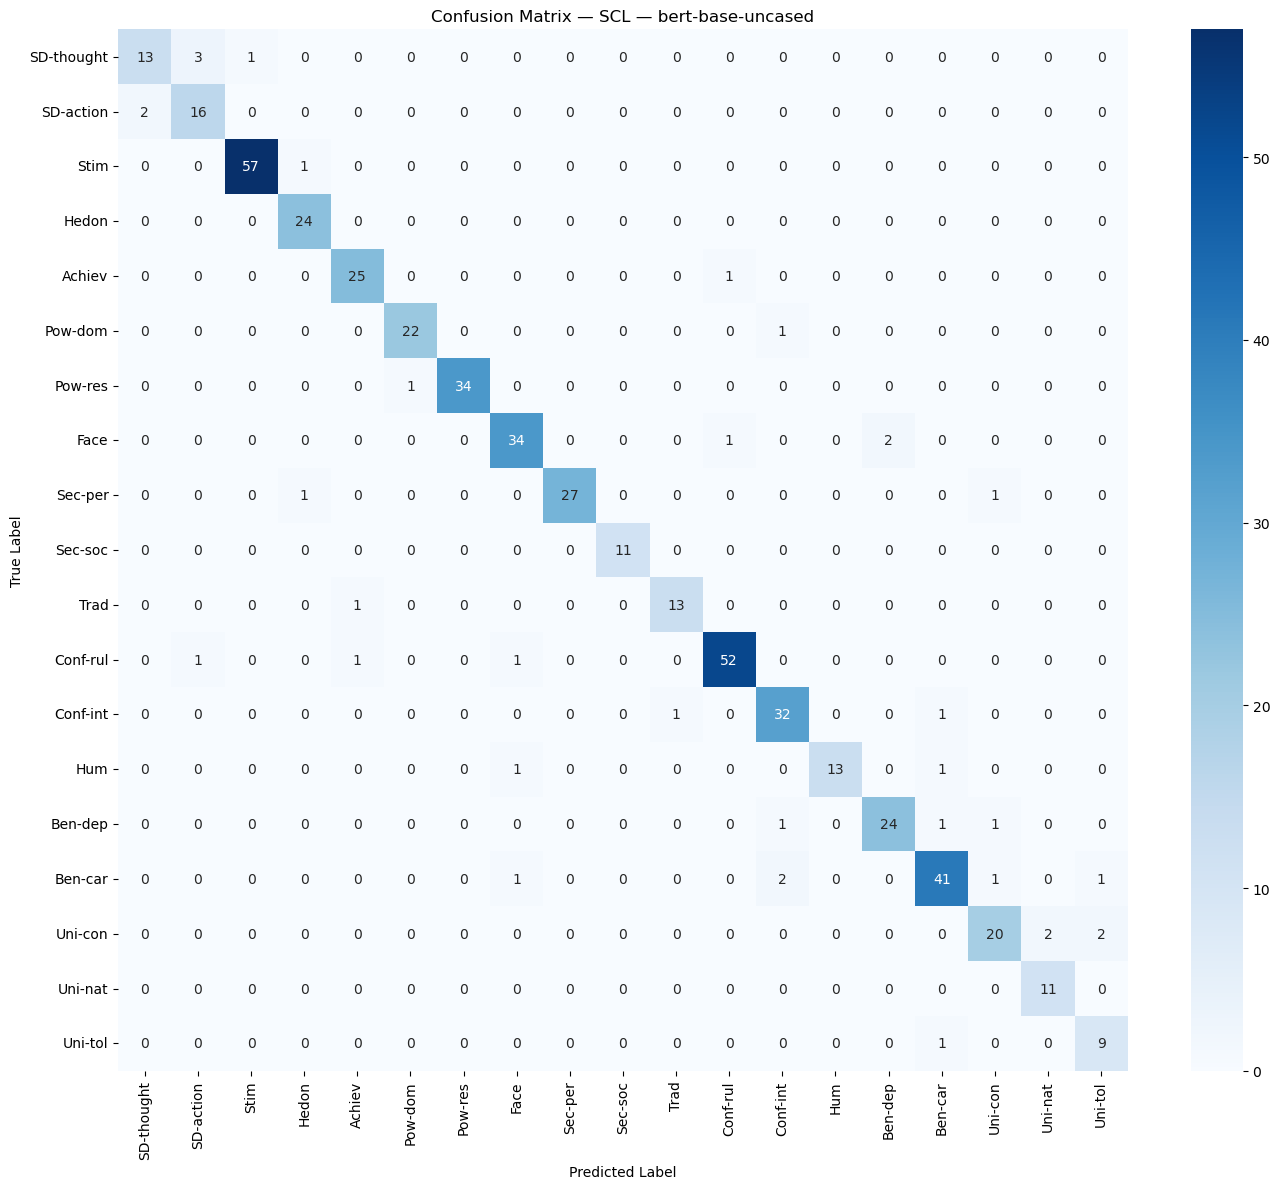

Confusion matrix saved to /home/yangdejin/nlpcc/nlpcc_task2/outputs/track1/encoder/bert_scl_optimized/confusion_matrix.png


In [9]:
# Cell 8: Dev 集综合评估 + 每类 F1 + 混淆矩阵热图
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

pred_output = trainer.predict(dev_dataset)
preds  = np.argmax(pred_output.predictions, axis=-1)
labels = np.array(dev_dataset["label"])

print("=" * 60)
print("Dev Set Evaluation Results — SCL")
print("=" * 60)
print(classification_report(
    labels, preds,
    target_names=VALUE_LABELS,
    digits=4
))

cm = confusion_matrix(labels, preds)
short_labels = [
    "SD-thought", "SD-action", "Stim", "Hedon", "Achiev",
    "Pow-dom", "Pow-res", "Face", "Sec-per", "Sec-soc",
    "Trad", "Conf-rul", "Conf-int", "Hum", "Ben-dep",
    "Ben-car", "Uni-con", "Uni-nat", "Uni-tol"
]

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=short_labels, yticklabels=short_labels
)
plt.title(f"Confusion Matrix — SCL — {MODEL_NAME}")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()
print(f"Confusion matrix saved to {OUTPUT_DIR}/confusion_matrix.png")